# Práctica: Convolutional Neural Networks y Transfer Learning con PyTorch

En esta práctica vamos a:

1. Implementar y entrenar desde cero una red neuronal convolucional (CNN) sencilla para clasificar dígitos MNIST.
2. Explorar la idea de **transfer learning** utilizando un modelo profundo preentrenado (ResNet18) y adaptándolo a un nuevo problema de clasificación (CIFAR-10).

La sesión está pensada para ejecutarse en GPU si está disponible (pero también funciona en CPU, solo que algo más lenta).


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import numpy as np
import time

# Comprobamos si hay GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## 1. Clasificación de dígitos MNIST con una CNN sencilla

Vamos a trabajar primero con MNIST, que son imágenes en escala de grises de 28×28 píxeles.

La CNN tendrá:
- Dos capas convolucionales + ReLU + MaxPooling.
- Dos capas totalmente conectadas al final.
- Función de pérdida: `CrossEntropyLoss`.
- Optimizador: `Adam`.

Entrenaremos unas pocas épocas para que el entrenamiento sea rápido.


In [ ]:
# Dataset temporal SOLO con ToTensor (sin Normalize)
tmp_transform = transforms.ToTensor()
tmp_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=tmp_transform)
tmp_loader = DataLoader(tmp_dataset, batch_size=1000, shuffle=False)

mean = 0.0
std = 0.0
num_batches = 0

for images, _ in tmp_loader:
    # images: [batch_size, C, H, W]
    batch_size = images.size(0)
    images = images.view(batch_size, images.size(1), -1)  # -> [B, C, H*W]

    # media y std por canal en este batch
    batch_mean = images.mean(dim=2).mean(dim=0)  # primero sobre píxeles, luego sobre el batch
    batch_std = images.std(dim=2).mean(dim=0)

    mean += batch_mean
    std += batch_std
    num_batches += 1

mean /= num_batches
std /= num_batches

print("Mean:", mean)
print("Std:", std)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.88MB/s]


Mean: tensor([0.1307])
Std: tensor([0.3015])


In [ ]:
# Transformaciones: tensor + normalización estándar de MNIST
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
])

train_mnist_full = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_transform)
test_mnist = datasets.MNIST(root="./data", train=False, download=True, transform=mnist_transform)

len(train_mnist_full), len(test_mnist)

(60000, 10000)

In [ ]:
# Para que el entrenamiento sea más rápido en clase, usamos un subconjunto del train
train_size = 10000  # de 60k
val_size = 2000

train_subset, _ = random_split(train_mnist_full, [train_size, len(train_mnist_full) - train_size])
train_mnist, val_mnist = random_split(train_subset, [train_size - val_size, val_size])

batch_size = 64

train_loader_mnist = DataLoader(train_mnist, batch_size=batch_size, shuffle=True)
val_loader_mnist = DataLoader(val_mnist, batch_size=batch_size, shuffle=False)
test_loader_mnist = DataLoader(test_mnist, batch_size=batch_size, shuffle=False)

len(train_loader_mnist), len(val_loader_mnist), len(test_loader_mnist)

(125, 32, 157)

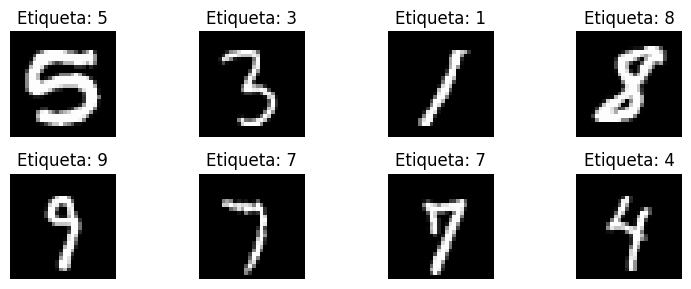

In [ ]:
examples = enumerate(train_loader_mnist)
batch_idx, (example_data, example_targets) = next(examples)

plt.figure(figsize=(8, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(example_data[i][0], cmap="gray")
    plt.title(f"Etiqueta: {example_targets[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Entrada: 1 x 28 x 28
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        # Después de conv1 + pool: 32 x 14 x 14
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # Después de conv2 + pool: 64 x 7 x 7
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 dígitos

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> 32 x 14 x 14
        x = self.pool(F.relu(self.conv2(x)))   # -> 64 x 7 x 7
        x = torch.flatten(x, 1)                # a vector por muestra
        x = F.relu(self.fc1(x))
        x = self.fc2(x)                        # logits (sin softmax)
        return x

model_cnn = SimpleCNN().to(device)
print(model_cnn)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
def train_one_epoch(model, device, dataloader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, device, dataloader, criterion=None):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            if criterion is not None:
                loss = criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = correct / total
    if criterion is not None:
        loss = running_loss / total
        return loss, acc
    else:
        return acc

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)

num_epochs = 20  # ajusta según el tiempo disponible

train_losses, val_losses = [], []
train_accs, val_accs = [], []

t0 = time.time()
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model_cnn, device, train_loader_mnist, optimizer, criterion)
    val_loss, val_acc = evaluate(model_cnn, device, val_loader_mnist, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Época {epoch+1}/{num_epochs}: "
          f"Train loss={train_loss:.4f}, acc={train_acc:.4f} | "
          f"Val loss={val_loss:.4f}, acc={val_acc:.4f}")

t1 = time.time()
print(f"Tiempo total de entrenamiento: {t1 - t0:.1f} s")

Época 1/20: Train loss=0.4762, acc=0.8528 | Val loss=0.1512, acc=0.9555
Época 2/20: Train loss=0.1176, acc=0.9640 | Val loss=0.0867, acc=0.9705
Época 3/20: Train loss=0.0754, acc=0.9774 | Val loss=0.0770, acc=0.9790
Época 4/20: Train loss=0.0495, acc=0.9846 | Val loss=0.0630, acc=0.9820
Época 5/20: Train loss=0.0352, acc=0.9890 | Val loss=0.0666, acc=0.9805
Época 6/20: Train loss=0.0232, acc=0.9922 | Val loss=0.0759, acc=0.9775
Época 7/20: Train loss=0.0202, acc=0.9934 | Val loss=0.0662, acc=0.9785
Época 8/20: Train loss=0.0168, acc=0.9942 | Val loss=0.0689, acc=0.9785
Época 9/20: Train loss=0.0090, acc=0.9978 | Val loss=0.0473, acc=0.9855
Época 10/20: Train loss=0.0026, acc=0.9996 | Val loss=0.0536, acc=0.9850
Época 11/20: Train loss=0.0024, acc=0.9996 | Val loss=0.0562, acc=0.9855
Época 12/20: Train loss=0.0013, acc=0.9998 | Val loss=0.0582, acc=0.9845
Época 13/20: Train loss=0.0007, acc=0.9999 | Val loss=0.0557, acc=0.9840
Época 14/20: Train loss=0.0007, acc=1.0000 | Val loss=0.0554

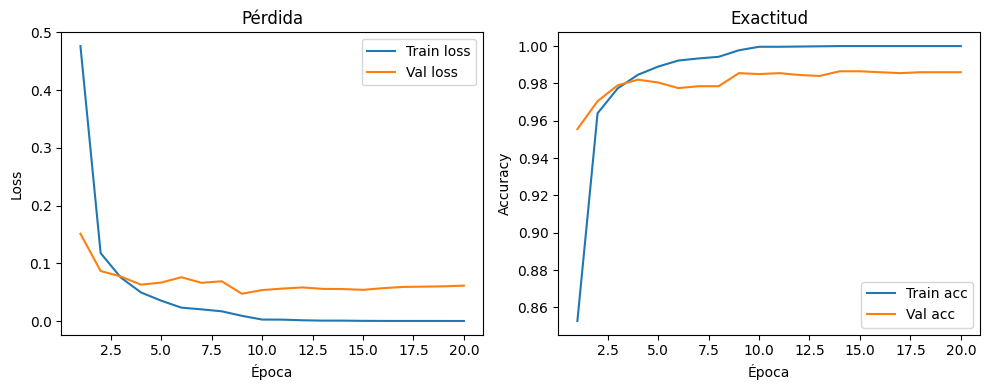

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Val loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.title("Pérdida")

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Train acc")
plt.plot(epochs, val_accs, label="Val acc")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Exactitud")

plt.tight_layout()
plt.show()

In [ ]:
test_loss_mnist, test_acc_mnist = evaluate(model_cnn, device, test_loader_mnist, criterion)
print(f"MNIST – Pérdida en test: {test_loss_mnist:.4f}, Accuracy en test: {test_acc_mnist:.4f}")

MNIST – Pérdida en test: 0.0687, Accuracy en test: 0.9843
